# Clase 10: Reduccion de dimensionalidad (PCA)

**Analitica de Datos**, Maestria en Ciencias del Comportamiento, Universidad de San Andres, Primavera 2026

**Lenguaje: Python.** La version equivalente en R esta disponible en el sitio de la materia.

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tomdamelio/analitica_de_datos/blob/main/clases/clase-10/notebooks/clase10_python.ipynb)

**Objetivo.** Introducir la reduccion de dimensionalidad, con foco en el analisis de componentes principales (PCA) y su utilidad para descubrir estructura en problemas de Ciencias del Comportamiento.

**Al terminar esta clase vas a poder:**

- explicar por que muchas variables correlacionadas se pueden resumir en pocas dimensiones;
- construir la intuicion de PCA en 2D y llevarla a 3 y mas dimensiones;
- calcular una PCA con scikit-learn e interpretar sus *loadings* y *scores* en un biplot;
- decidir cuando estandarizar y cuantos componentes retener (scree plot, varianza acumulada);
- aplicar PCA (y combinarlo con clustering) para descubrir perfiles latentes de comportamiento.

*Lectura obligatoria:* James et al. (2023), *An Introduction to Statistical Learning*, **capitulo 12** (secciones 12.1 y 12.2). La intuicion inicial retoma tambien la Seccion 6.3.1.

In [1]:
#| include: false
#@title Identidad visual de la materia (ejecutar y seguir) { display-mode: "form" }
from IPython.display import HTML, display

display(HTML(r"""
<style>
@import url('https://fonts.googleapis.com/css2?family=Work+Sans:wght@400;600&family=Amiri:wght@400;700&display=swap');
.rendered_html, .markdown, .cell .text_cell_render { font-family:'Work Sans',system-ui,sans-serif; color:#122535; }
.rendered_html h1,.rendered_html h2,.rendered_html h3 { font-family:'Amiri',Georgia,serif; color:#00529B; }
.rendered_html h2 { border-bottom:2px solid #00529B; padding-bottom:.2em; }
.rendered_html a { color:#00529B; }
.rendered_html table th { background:#00529B; color:#fff; }
.rendered_html h1,.rendered_html h2,.rendered_html h3 { scroll-margin-top:16px; }
</style>
"""))

## Contenidos de hoy

| # | Tema | La idea en una linea |
|---|------|----------------------|
| 1 | [Motivacion: demasiadas variables](#s1) | muchas columnas correlacionadas esconden pocas dimensiones reales |
| 2 | [PCA en dos dimensiones](#s2) | la primera componente es la recta de maxima varianza |
| 3 | [De 2D a muchas dimensiones](#s3) | pocas direcciones resumen una nube de alta dimension |
| 3.1 | [Reconstruir un dato](#s3r) | comprimir sirve si se puede volver del resumen al dato |
| 4 | [Decisiones practicas: escalar y cuantos componentes](#s4) | estandarizar casi siempre; retener hasta el codo del scree plot |
| 5 | [Metodos no lineales: t-SNE y UMAP](#s5) | cuando la estructura no es lineal, PCA se queda corto |
| 6 | [Ejercicio: perfiles latentes en attrition](#s6) | aplicar PCA + clustering a datos que ya conoces |
|   | [Autoevaluacion](#quiz), [Cierre](#cierre) | |

*Tip: hace click en cualquier tema para saltar directo.* Los ejercicios estan intercalados en la seccion que les corresponde.

## Donde se ubica esta clase en la materia

Seguimos en el Eje III, aprendizaje **no supervisado**: datos sin variable a predecir, donde el objetivo es descubrir estructura. En la Clase 9 agrupamos observaciones con clustering; hoy reducimos **variables**, y al final combinamos las dos ideas.

**Sobre que se apoya.** La nocion de varianza y correlacion de Estadistica; las combinaciones lineales y proyecciones del algebra lineal; y el K-means de la Clase 9, que reaparece en el ejercicio final.

**A que habilita.** Representar datos de alta dimension en pocas coordenadas es la base de los *embeddings* de las Clases 11 y 12 (NLP), y una herramienta central para el proyecto final.

| se apoya en | esta clase | habilita |
|---|---|---|
| Varianza y correlacion; proyecciones lineales; K-means (Clase 9) | PCA: de la intuicion 2D a datos de alta dimension | Embeddings en NLP (Clases 11 a 12); proyecto final |

## El hilo de hoy

Muchas variables academicas correlacionadas de cada estudiante $\to$ mirarlas todas es imposible (hay $p(p-1)/2$ scatterplots) $\to$ en 2D, PCA encuentra la **recta de maxima varianza** $\to$ la misma idea escala a 3 y mas dimensiones, y la leemos en un **biplot** $\to$ decidimos **estandarizar** y **cuantos componentes** retener $\to$ vemos que t-SNE y UMAP capturan estructura no lineal $\to$ aplicamos todo a un dataset que ya conoces (attrition) para descubrir **perfiles latentes**.

A lo largo de la clase nos acompana un dataset real de **desercion y exito academico**: 4424 estudiantes de educacion superior. Vamos a ver que PCA encuentra, casi sola, un eje que separa a quienes desertan de quienes se graduan.

In [2]:
#| include: false
#@title Configuracion de la materia (parametros, colores y funciones)  { display-mode: "form" }
# Setup: librerias, semilla, estilo de figuras y helpers de la materia
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import HTML, display

SEED = 42
np.random.seed(SEED)

# Paleta semantica de la materia (misma que theme/tokens.yml del sitio)
COL = {
    "primary": "#00529B",  # azul institucional: la serie principal
    "accent":  "#C0492F",  # terracota: el contraste
    "good":    "#1F7A4D",  # verde: correcto / esperado
    "bad":     "#B4232E",  # rojo: problema / alerta
    "muted":   "#7E9EBB",  # azul apagado: geometria secundaria
    "ink":     "#122535",  # tinta: texto y ejes
    "grey":    "#9FB0BD",  # gris azulado: grillas
}
plt.rcParams.update({
    "figure.dpi": 120, "figure.figsize": (7, 4),
    "axes.edgecolor": COL["ink"], "axes.labelcolor": COL["ink"],
    "text.color": COL["ink"], "xtick.color": COL["ink"], "ytick.color": COL["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11,
})

# En Colab las figuras se guardan en ./figures; al renderizar el sitio, en assets de la clase
EN_COLAB = False
try:
    import google.colab  # noqa: F401
    EN_COLAB = True
except ImportError:
    pass
FIG_DIR = Path("figures") if EN_COLAB else Path("../assets/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def guardar_figura(nombre):
    """Guarda la figura actual como PNG (dpi 150) con el nombre de la convencion de la materia."""
    plt.savefig(FIG_DIR / (nombre + ".png"), dpi=150, bbox_inches="tight")

def tiles(items):
    """Tarjetas con numeros clave: lista de (etiqueta, valor, lectura)."""
    celdas = "".join(
        '<div style="flex:1;min-width:130px;border:1px solid #9FB0BD;border-radius:8px;'
        'padding:.6em .9em;margin:.3em">'
        '<div style="font-size:.8em;color:#7E9EBB">' + lab + '</div>'
        '<div style="font-size:1.5em;font-weight:600;color:#00529B">' + val + '</div>'
        '<div style="font-size:.75em;color:#7E9EBB">' + cap + '</div></div>'
        for lab, val, cap in items)
    return HTML('<div style="display:flex;flex-wrap:wrap">' + celdas + '</div>')

# URL publica y estable del dataset (repo oficial de IBM); la cargamos en la seccion 2
URL_DATOS = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"
print("Setup listo. Semilla fija en", SEED)

# --- Especifico de la Clase 10 (reduccion de dimensionalidad) ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import ipywidgets as W
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"
try:
    from google.colab import output as _co
    _co.enable_custom_widget_manager()
except Exception:
    pass

# Dataset que acompana la clase: desercion y exito academico (UCI id 697, CC BY 4.0).
# Fuente oficial y estable; en Colab se descarga en el momento.
def cargar_desercion():
    import io, zipfile, urllib.request
    url = "https://archive.ics.uci.edu/static/public/697/predict+students+dropout+and+academic+success.zip"
    raw = urllib.request.urlopen(url, timeout=60).read()
    df = pd.read_csv(zipfile.ZipFile(io.BytesIO(raw)).open("data.csv"), sep=";")
    df.columns = [c.strip() for c in df.columns]
    return df

COL_TARGET = {"Dropout": COL["bad"], "Graduate": COL["good"], "Enrolled": COL["grey"]}

def callout(cuerpo, tipo="info", titulo=None):
    pal = {"info": ("#00529B", "#eaf1f8"), "success": ("#1F7A4D", "#e8f3ec"),
           "warn": ("#B4232E", "#fbeceb"), "neutral": ("#7E9EBB", "#eef2f6")}
    edge, bg = pal.get(tipo, pal["info"])
    head = ('<div style="font-weight:600;color:' + edge + ';margin-bottom:.3em">' + titulo + '</div>') if titulo else ""
    return HTML('<div style="border-left:4px solid ' + edge + ';background:' + bg +
                ';padding:.7em 1em;border-radius:4px;margin:.6em 0">' + head + cuerpo + '</div>')

def biplot(scores, loadings, labels, titulo, nombre=None, grupos=None, paleta=None):
    # scores: n x >=2. loadings: 2 x p. grupos: array categorico opcional para colorear.
    esc = np.abs(scores[:, :2]).max() / (np.abs(loadings[:2, :]).max() + 1e-9) * 0.62
    fig, ax = plt.subplots(figsize=(7, 7))
    if grupos is None:
        ax.scatter(scores[:, 0], scores[:, 1], s=8, color=COL["muted"], alpha=0.45)
    else:
        for g in pd.unique(grupos):
            m = np.asarray(grupos) == g
            ax.scatter(scores[m, 0], scores[m, 1], s=8, alpha=0.45,
                       color=(paleta.get(g) if paleta else None), label=str(g))
        ax.legend(markerscale=2, framealpha=0.9)
    for k, lab in enumerate(labels):
        ax.arrow(0, 0, esc * loadings[0, k], esc * loadings[1, k], color=COL["ink"],
                 width=0.003, head_width=0.09, length_includes_head=True, alpha=0.9)
        ax.text(esc * loadings[0, k] * 1.13, esc * loadings[1, k] * 1.13, lab,
                color=COL["ink"], fontsize=9, ha="center", va="center", fontweight="bold")
    ax.axhline(0, color=COL["grey"], lw=0.8); ax.axvline(0, color=COL["grey"], lw=0.8)
    ax.margins(0.14)
    ax.set_xlabel("Componente principal 1"); ax.set_ylabel("Componente principal 2")
    ax.set_title(titulo, pad=14)
    if nombre:
        guardar_figura(nombre)
    plt.show()

print("Setup Clase 10 listo.")

Setup listo. Semilla fija en 42


Setup Clase 10 listo.


<a name="s1"></a>
## 1. Motivacion: demasiadas variables

**La idea.** El aprendizaje no supervisado no tiene una variable a predecir: su objetivo es **descubrir estructura** en un conjunto de features, casi siempre como parte de un analisis exploratorio. Un sitio de compras online, por ejemplo, agrupa a sus clientes segun su historial de navegacion y compra para recomendarle a cada uno lo que le interesa, sin ninguna etiqueta que diga de antemano a que grupo pertenece cada persona.

PCA ataca una version de ese problema: cuando hay **muchas variables correlacionadas**, permite resumirlas con unas pocas variables representativas que conservan casi toda la variabilidad. El problema practico es doble. Primero, **no se pueden mirar**: con $p$ variables hay $p(p-1)/2$ diagramas de dispersion posibles, y con $p=10$ ya son 45. Segundo, muchas variables son en parte **ruido**. Empezamos midiendo cuanta redundancia hay en un dataset real de desercion academica.

Estudiantes: 4424 | variables del bloque: 8 | scatterplots posibles: 28
Desenlace (Target): {'Graduate': np.int64(2209), 'Dropout': np.int64(1421), 'Enrolled': np.int64(794)}


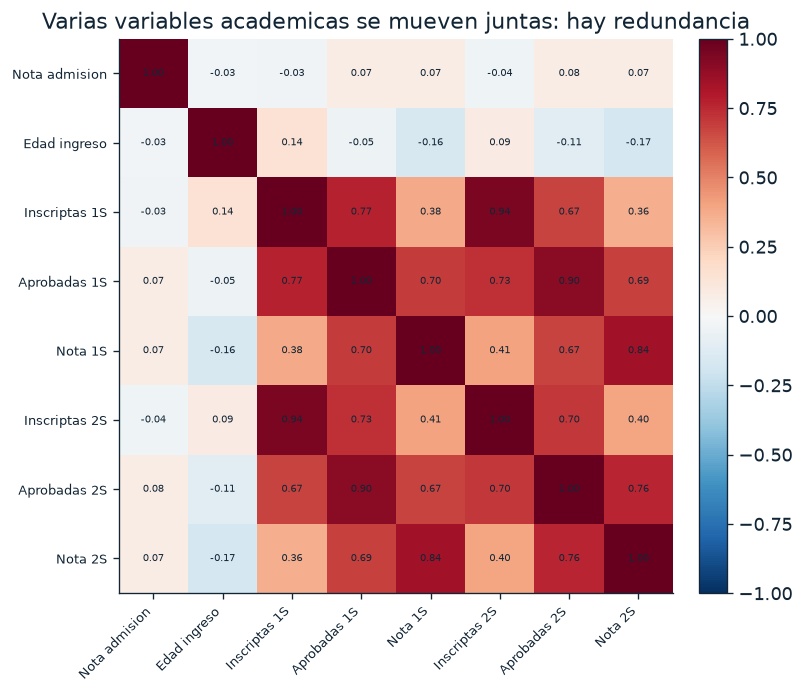

In [3]:
# Dataset que nos acompana toda la clase: desercion y exito academico (UCI, CC BY 4.0)
est = cargar_desercion()

# Bloque de variables academicas numericas, con sentido sustantivo comun
academico = ["Admission grade", "Age at enrollment",
             "Curricular units 1st sem (enrolled)", "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
             "Curricular units 2nd sem (enrolled)", "Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)"]
etq = {"Admission grade": "Nota admision", "Age at enrollment": "Edad ingreso",
       "Curricular units 1st sem (enrolled)": "Inscriptas 1S", "Curricular units 1st sem (approved)": "Aprobadas 1S",
       "Curricular units 1st sem (grade)": "Nota 1S", "Curricular units 2nd sem (enrolled)": "Inscriptas 2S",
       "Curricular units 2nd sem (approved)": "Aprobadas 2S", "Curricular units 2nd sem (grade)": "Nota 2S"}

X = est[academico]
p = X.shape[1]
n_scatter = p * (p - 1) // 2
print("Estudiantes:", est.shape[0], "| variables del bloque:", p, "| scatterplots posibles:", n_scatter)
print("Desenlace (Target):", dict(est["Target"].value_counts()))

R = X.corr()
# Verificacion: las materias aprobadas en 1er y 2do semestre estan muy correlacionadas
assert R.loc["Curricular units 1st sem (approved)", "Curricular units 2nd sem (approved)"] > 0.85

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(R.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(p)); ax.set_xticklabels([etq[c] for c in academico], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(p)); ax.set_yticklabels([etq[c] for c in academico], fontsize=8)
for i in range(p):
    for j in range(p):
        ax.text(j, i, format(R.values[i, j], ".2f"), ha="center", va="center", fontsize=6, color=COL["ink"])
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Varias variables academicas se mueven juntas: hay redundancia")
guardar_figura("clase10_correlaciones")
plt.show()

display(callout("Con solo " + str(p) + " variables ya hay " + str(n_scatter) +
                " scatterplots posibles, y ninguno muestra la foto completa. PCA busca, en cambio, "
                "unas pocas direcciones que resuman toda la nube. Empecemos con la version mas simple: dos variables.",
                tipo="info", titulo="Por que necesitamos reducir"))

<a name="s2"></a>
## 2. PCA en dos dimensiones

**La idea.** Antes de ir a muchas variables, la intuicion se ve entera en 2D. Tomamos dos variables muy correlacionadas: las materias **aprobadas en el primer y el segundo semestre**. Los puntos forman una nube alargada en diagonal.

La **primera componente principal** es la direccion a lo largo de la cual los puntos **varian mas**. Tiene una segunda lectura equivalente: es tambien la recta **mas cercana** a todos los puntos (la que minimiza las distancias). Proyectar cada estudiante sobre esa recta da su **score**: un unico numero que resume sus dos variables. Aca ese numero es, en la practica, "cuantas materias aprueba": un indice de avance academico.

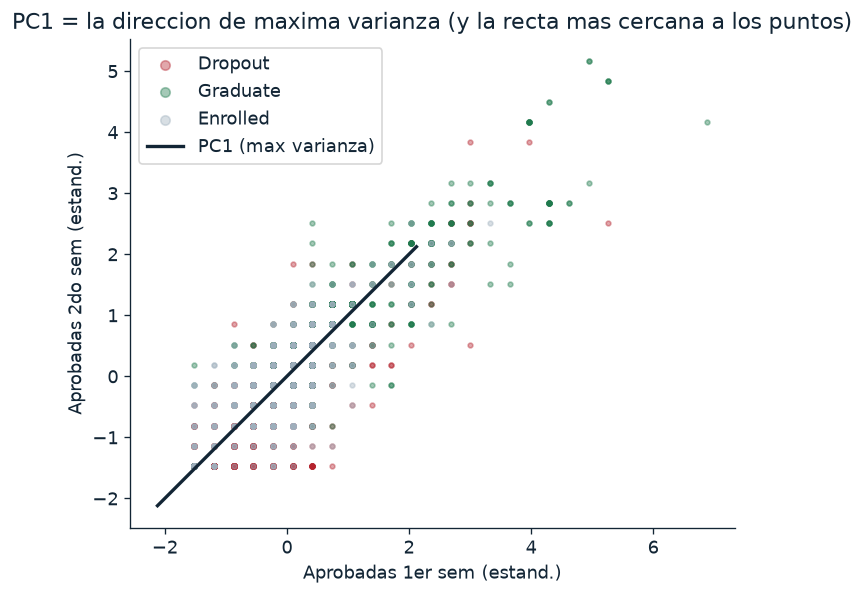

In [4]:
# Dos variables muy correlacionadas: aprobadas en 1er y 2do semestre
par = ["Curricular units 1st sem (approved)", "Curricular units 2nd sem (approved)"]
D = est[par].to_numpy(dtype=float)
Ds = StandardScaler().fit_transform(D)
pca2 = PCA().fit(Ds)
v1 = pca2.components_[0]            # direccion de la primera componente
if v1.sum() < 0: v1 = -v1
pve2 = pca2.explained_variance_ratio_
assert pve2[0] > 0.9               # con r ~ 0.9, PC1 concentra casi toda la varianza

# Recta de PC1 sobre la nube (en el espacio estandarizado)
t = np.linspace(-3, 3, 2)
fig, ax = plt.subplots(figsize=(6.5, 6))
for g in ["Dropout", "Graduate", "Enrolled"]:
    m = est["Target"].to_numpy() == g
    ax.scatter(Ds[m, 0], Ds[m, 1], s=8, alpha=0.4, color=COL_TARGET[g], label=g)
ax.plot(t * v1[0], t * v1[1], color=COL["ink"], lw=2, label="PC1 (max varianza)")
ax.set_xlabel("Aprobadas 1er sem (estand.)"); ax.set_ylabel("Aprobadas 2do sem (estand.)")
ax.set_title("PC1 = la direccion de maxima varianza (y la recta mas cercana a los puntos)")
ax.legend(markerscale=2); ax.set_aspect("equal")
guardar_figura("clase10_pca2d")
plt.show()

display(tiles([("PC1", format(pve2[0] * 100, ".1f") + "%", "de la varianza en 1 eje"),
               ("PC2", format(pve2[1] * 100, ".1f") + "%", "lo que queda"),
               ("Correlacion", format(np.corrcoef(D[:, 0], D[:, 1])[0, 1], ".2f"), "entre las 2 variables")]))

In [5]:
# Laboratorio interactivo: por que "maxima varianza"
# Rotamos una direccion y miramos la varianza de los puntos proyectados sobre ella.
angs = np.linspace(0, 180, 181)
var_ang = np.array([np.var(Ds @ np.array([np.cos(np.deg2rad(a)), np.sin(np.deg2rad(a))])) for a in angs])
best = angs[int(np.argmax(var_ang))]

def _proyeccion(angulo):
    u = np.array([np.cos(np.deg2rad(angulo)), np.sin(np.deg2rad(angulo))])
    fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
    axs[0].scatter(Ds[:, 0], Ds[:, 1], s=6, color=COL["muted"], alpha=0.4)
    axs[0].plot([-3 * u[0], 3 * u[0]], [-3 * u[1], 3 * u[1]], color=COL["accent"], lw=2)
    axs[0].set_xlim(-4, 4); axs[0].set_ylim(-4, 4); axs[0].set_aspect("equal")
    axs[0].set_xlabel("Aprobadas 1S (estand.)"); axs[0].set_ylabel("Aprobadas 2S (estand.)")
    axs[0].set_title("Direccion a " + str(angulo) + " grados")
    axs[1].plot(angs, var_ang, color=COL["primary"])
    axs[1].axvline(angulo, color=COL["accent"], label="tu direccion")
    axs[1].axvline(best, color=COL["good"], ls="--", label="maximo = PC1")
    axs[1].set_xlabel("Angulo de la direccion (grados)"); axs[1].set_ylabel("Varianza proyectada")
    axs[1].set_title("La varianza se maximiza cerca de " + format(best, ".0f") + " grados"); axs[1].legend()
    plt.show()

sl = W.IntSlider(value=15, min=0, max=180, step=5, description="angulo", continuous_update=False)
display(W.VBox([sl, W.interactive_output(_proyeccion, {"angulo": sl})]))

### Las dos lecturas, en una sola animacion

<img src="https://raw.githubusercontent.com/tomdamelio/analitica_de_datos/main/clases/clase-10/assets/figures/PCA-errors.gif" alt="Una recta que rota sobre una nube de puntos, mostrando las proyecciones de los puntos y los errores de proyeccion" width="620">

Mientras la recta gira, mira dos cosas al mismo tiempo. Los **segmentos rojos** son los errores de proyeccion: la distancia de cada punto a la recta. Los **puntos rojos** apoyados sobre la recta son las proyecciones, y lo estirada que queda esa nube de proyecciones es la varianza proyectada.

Cuando la recta alcanza la direccion de la primera componente pasan las dos cosas a la vez: los segmentos llegan a su longitud total minima y, en ese mismo instante, las proyecciones quedan lo mas dispersas posible. No son dos propiedades distintas que coinciden por casualidad, son la misma condicion escrita de dos maneras. Es la equivalencia que vamos a reencontrar en la Seccion 3.1, cuando veamos que minimizar el error de reconstruccion y maximizar la varianza explicada son el mismo problema.

**Predecir.** Si dos variables estuvieran *perfectamente* correlacionadas, cuanta varianza explicaria PC1?

<details><summary>Ver respuesta</summary>

Casi toda. Dos variables perfectamente correlacionadas viven sobre una recta: una sola direccion (PC1) captura el 100% de su variacion y la segunda no aporta nada. PCA rinde justamente cuando hay correlacion.

</details>

<a name="s3"></a>
## 3. De dos dimensiones a muchas

**La idea.** En 2D vimos una recta; en 3D, las **dos** primeras componentes definen el **plano mas cercano** a la nube (el que mejor la resume). El grafico interactivo de abajo muestra la nube de estudiantes en tres variables academicas y ese plano: giralo con el mouse para ver como se apoya sobre los datos.

Con $p$ variables la idea es la misma, aplicada sucesivamente: cada componente es una combinacion lineal normalizada de las variables

$$Z_m = \phi_{1m} X_1 + \phi_{2m} X_2 + \cdots + \phi_{pm} X_p, \qquad \sum_j \phi_{jm}^2 = 1$$

donde los coeficientes $\phi_{jm}$ son los **loadings** (cuanto pesa cada variable en la componente $m$) y los valores $Z_m$ son los **scores**. Cada componente maximiza la varianza sujeta a ser **ortogonal** (no correlacionada) a las anteriores. Un **biplot** muestra todo junto: los puntos son los scores; las flechas, los loadings.

In [6]:
# Vista interactiva 3D: el plano de las dos primeras componentes (interpretacion de la Figura 12.2)
tri = ["Curricular units 1st sem (approved)", "Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)"]
T = StandardScaler().fit_transform(est[tri].to_numpy(dtype=float))
rng = np.random.default_rng(SEED)
idx = rng.choice(len(T), size=250, replace=False)   # submuestra para que el 3D sea liviano
Tv = T[idx]
pc3 = PCA(n_components=2).fit(T)
v1, v2 = pc3.components_[0], pc3.components_[1]

# Malla del plano generado por PC1 y PC2
gs = np.linspace(-3, 3, 12)
aa, bb = np.meshgrid(gs, gs)
plano = aa[..., None] * v1 + bb[..., None] * v2       # puntos del plano en el espacio 3D
tg = est["Target"].to_numpy()[idx]

fig = go.Figure()
fig.add_surface(x=plano[:, :, 0], y=plano[:, :, 1], z=plano[:, :, 2],
                opacity=0.5, showscale=False, colorscale=[[0, COL["muted"]], [1, COL["muted"]]])
for g in ["Dropout", "Graduate", "Enrolled"]:
    m = tg == g
    fig.add_scatter3d(x=Tv[m, 0], y=Tv[m, 1], z=Tv[m, 2], mode="markers",
                      marker=dict(size=3, color=COL_TARGET[g]), name=g)
fig.update_layout(title="Las 2 primeras componentes definen el plano mas cercano a la nube",
                  scene=dict(xaxis_title="Aprobadas 1S", yaxis_title="Aprobadas 2S", zaxis_title="Nota 2S",
                             camera=dict(eye=dict(x=1.9, y=0.5, z=1.4))),
                  height=560, margin=dict(l=0, r=0, t=40, b=0))
fig.show()
try:
    fig.write_image(str(FIG_DIR / "clase10_3d.png"), width=900, height=620, scale=2)
except Exception as e:
    print("(figura estatica 3D omitida:", type(e).__name__, ")")

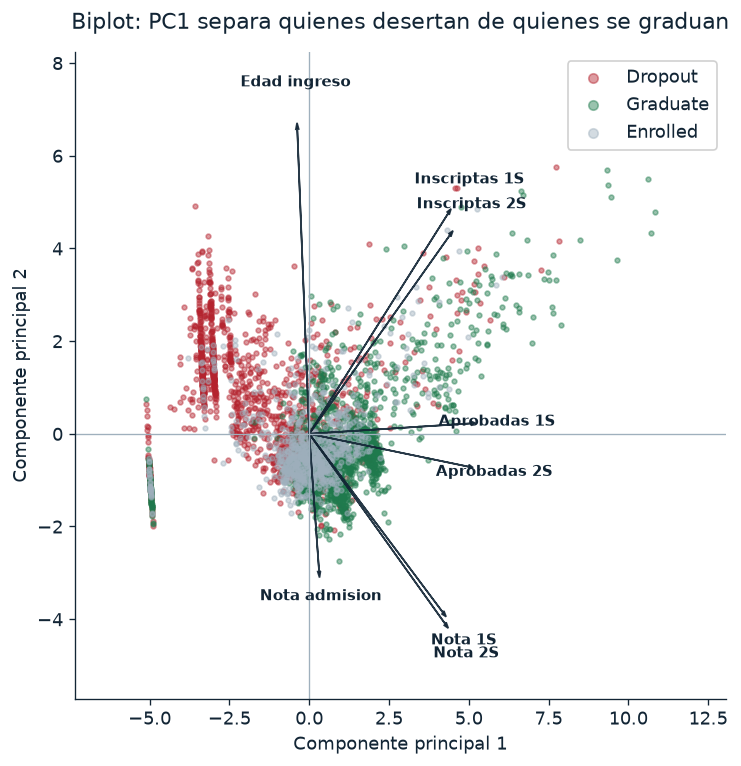

Loadings PC1: {'Nota admision': np.float64(0.03), 'Edad ingreso': np.float64(-0.03), 'Inscriptas 1S': np.float64(0.39), 'Aprobadas 1S': np.float64(0.45), 'Nota 1S': np.float64(0.37), 'Inscriptas 2S': np.float64(0.39), 'Aprobadas 2S': np.float64(0.45), 'Nota 2S': np.float64(0.38)}


In [7]:
# Biplot sobre el bloque academico completo (8 variables), coloreado por el desenlace
Xs = StandardScaler().fit_transform(X)
pca = PCA().fit(Xs)
scores = pca.transform(Xs)
comp = pca.components_.copy()
pve = pca.explained_variance_ratio_

# Orientar PC1 para que crezca con el exito academico (graduados con score alto)
grad = est["Target"].to_numpy() == "Graduate"
drop = est["Target"].to_numpy() == "Dropout"
if scores[grad, 0].mean() < scores[drop, 0].mean():
    comp[0] *= -1; scores[:, 0] *= -1
assert scores[grad, 0].mean() > scores[drop, 0].mean()   # PC1 alto = graduarse

# El libro hace este mismo analisis sobre USArrests (Fig. 12.1); aca lo hacemos sobre desercion.
display(tiles([("PC1", format(pve[0] * 100, ".1f") + "%", "exito / riesgo academico"),
               ("PC2", format(pve[1] * 100, ".1f") + "%", "segundo eje"),
               ("PC1 + PC2", format(pve[:2].sum() * 100, ".1f") + "%", "resumen en 2D")]))
biplot(scores, comp[:2], [etq[c] for c in academico],
       "Biplot: PC1 separa quienes desertan de quienes se graduan",
       "clase10_biplot", grupos=est["Target"].to_numpy(), paleta=COL_TARGET)

print("Loadings PC1:", dict(zip([etq[c] for c in academico], np.round(comp[0], 2))))

El resultado es el que anticipaba la lectura: sin usar en ningun momento la etiqueta de desercion, **PC1 termina siendo un eje de riesgo academico**. Los estudiantes con score alto (muchas materias aprobadas y buenas notas) son casi todos graduados; los de score bajo, desertores. PCA descubrio sola esa estructura. Es la misma logica con la que el libro interpreta, sobre `USArrests`, que su PC1 mide el nivel de criminalidad de cada estado.

### Como se lee un biplot

Un biplot no es un grafico, son **dos graficos superpuestos** sobre los mismos ejes, y cada uno tiene su propia escala.

1. **Los scores.** Cada punto es un estudiante, ubicado por su valor en la primera componente (eje horizontal) y en la segunda (eje vertical). Hasta aca es un scatterplot comun, solo que las dos coordenadas ya no son variables medidas sino combinaciones lineales de todas las variables.
2. **Los loadings.** Cada flecha es una variable original, dibujada desde el origen hasta el punto formado por su peso en la primera componente y su peso en la segunda. Como los pesos viven en una escala mucho mas chica que los scores, el biplot los multiplica por un factor comun para que las flechas se vean; ese factor es el mismo para todas, asi que las comparaciones entre flechas siguen siendo validas.

De las flechas se leen tres cosas, y conviene mirarlas en este orden.

**Direccion: que mezcla de componentes representa a esa variable.** Una flecha que apunta casi horizontal es una variable que carga casi solo sobre la primera componente; una casi vertical carga sobre la segunda; una diagonal, sobre las dos. La direccion es lo que permite ponerle nombre sustantivo a cada eje: si todas las flechas de rendimiento apuntan hacia la derecha, el eje horizontal es un eje de rendimiento.

**Angulo entre flechas: cuanto se parecen dos variables.** Flechas que apuntan casi para el mismo lado corresponden a variables muy correlacionadas entre si; flechas casi perpendiculares, a variables practicamente sin correlacion; flechas opuestas, a variables correlacionadas negativamente. La razon es que el coseno del angulo entre dos flechas aproxima la correlacion entre las dos variables, y la aproximacion es buena en la medida en que las dos esten bien representadas en el plano.

**Longitud: que tan bien queda representada esa variable en este plano.** Una flecha larga indica una variable que las dos primeras componentes capturan bien; una flecha corta indica una variable que vive sobre todo en las componentes que no estamos mirando, y sobre ella el biplot no dice casi nada. Ojo con este criterio: en un biplot dibujado con los pesos crudos, como el de arriba, la longitud es solo una guia aproximada, porque la primera componente tiene mas varianza que la segunda y esa diferencia no esta en el dibujo. La version objetiva se calcula, y es lo que hacemos en la celda que sigue.

La cantidad que hace objetiva la lectura es la **varianza de cada variable captada por las dos primeras componentes**:

$$c_j = \lambda_1 \phi_{j1}^2 + \lambda_2 \phi_{j2}^2$$

donde:

- $c_j$ es la varianza de la variable $j$ que reconstruyen las dos primeras componentes, tambien llamada **comunalidad en dos dimensiones**;
- $\lambda_1$ y $\lambda_2$ son las varianzas de la primera y la segunda componente;
- $\phi_{j1}$ y $\phi_{j2}$ son los pesos (loadings) de la variable $j$ en cada una de esas dos componentes.

Como las variables estan estandarizadas, cada una tiene varianza 1 y entonces $c_j$ se lee directo como **proporcion**: un valor cercano a 1 significa que el plano del biplot representa casi toda esa variable, y un valor cercano a 0, que casi no la representa. En la misma linea, $\sqrt{\lambda_1}\,\phi_{j1}$ es la correlacion entre la variable $j$ y la primera componente.

In [8]:
# Lectura objetiva del biplot: direccion, angulo y longitud de cada flecha
ang = np.degrees(np.arctan2(comp[1], comp[0])) % 360      # direccion de cada flecha, en grados desde el eje PC1
largo2 = comp[0] ** 2 + comp[1] ** 2                       # longitud al cuadrado de la flecha tal como esta dibujada
lam = pca.explained_variance_[:2]                          # varianza de PC1 y de PC2
var_cap = lam[0] * comp[0] ** 2 + lam[1] * comp[1] ** 2    # comunalidad 2D: varianza de la variable captada por el plano

tabla_biplot = pd.DataFrame({"Variable": [etq[c] for c in academico],
                             "Loading PC1": comp[0].round(2), "Loading PC2": comp[1].round(2),
                             "Angulo": ang.round(0), "Largo^2 dibujado": largo2.round(3),
                             "Varianza captada": var_cap.round(2)}
                            ).sort_values("Varianza captada", ascending=False).reset_index(drop=True)
print(tabla_biplot.to_string(index=False))

def angulo_entre(a, b):
    """Angulo entre las flechas de dos variables, en grados: 0 = misma direccion, 90 = perpendiculares."""
    d = abs(ang[academico.index(a)] - ang[academico.index(b)]) % 360
    return min(d, 360 - d)

R = X.corr()
juntas = ("Curricular units 1st sem (enrolled)", "Curricular units 2nd sem (enrolled)")
cruz   = ("Age at enrollment", "Curricular units 1st sem (approved)")
peor   = academico[int(np.argmin(var_cap))]
print()
print("Flechas casi paralelas:", etq[juntas[0]], "y", etq[juntas[1]],
      "-> angulo", round(angulo_entre(*juntas), 1), "grados, correlacion", round(R.loc[juntas], 2))
print("Flechas casi perpendiculares:", etq[cruz[0]], "y", etq[cruz[1]],
      "-> angulo", round(angulo_entre(*cruz), 1), "grados, correlacion", round(R.loc[cruz], 2))
print("Variable peor representada en el plano:", etq[peor], "-> varianza captada", round(float(var_cap.min()), 2))

# Cuanto representa el eje horizontal a cada variable: su correlacion con la PC1
cor_pc1 = np.sqrt(lam[0]) * comp[0]
print("\nCorrelacion de cada variable con PC1:",
      dict(zip([etq[c] for c in academico], np.round(cor_pc1, 2))))

# Verificaciones independientes de cada afirmacion que hacemos en el texto
assert angulo_entre(*juntas) < 10 and R.loc[juntas] > 0.85          # juntas <-> muy correlacionadas
assert 70 < angulo_entre(*cruz) < 110 and abs(R.loc[cruz]) < 0.2    # perpendiculares <-> casi sin correlacion
assert peor == "Admission grade" and var_cap.min() < 0.2            # la nota de admision es la que peor entra
assert np.isclose(largo2[academico.index(peor)], largo2.min())      # y tambien es la flecha mas corta dibujada
assert np.allclose(largo2, [comp[:2, k] @ comp[:2, k] for k in range(p)])
assert np.allclose(var_cap, [np.sum(lam * comp[:2, k] ** 2) for k in range(p)])
assert var_cap.max() < 1.0            # ninguna variable queda captada del todo por solo dos componentes
mejor = academico[int(np.argmax(np.abs(cor_pc1)))]
assert abs(cor_pc1[academico.index(mejor)]) > 0.9

display(callout("Las cuatro variables de materias (inscriptas y aprobadas en los dos semestres) tienen loadings de PC1 "
                "del mismo signo y de magnitud parecida: son las que definen el eje horizontal. La que mas se alinea "
                "con PC1 es " + etq[mejor] + ", con una correlacion de " + format(cor_pc1[academico.index(mejor)], ".2f") +
                ". La nota de admision, en cambio, casi no aparece en el plano: su varianza captada es " +
                format(var_cap.min(), ".2f") + ", asi que sobre ella el biplot no autoriza ninguna lectura.",
                tipo="info", titulo="Lo que dice la tabla"))

     Variable  Loading PC1  Loading PC2  Angulo  Largo^2 dibujado  Varianza captada
 Aprobadas 1S         0.45         0.02     3.0             0.207              0.90
Inscriptas 1S         0.39         0.42    48.0             0.330              0.90
 Aprobadas 2S         0.45        -0.06   352.0             0.205              0.88
Inscriptas 2S         0.39         0.38    44.0             0.301              0.87
      Nota 2S         0.38        -0.37   316.0             0.279              0.81
      Nota 1S         0.37        -0.34   317.0             0.259              0.77
 Edad ingreso        -0.03         0.59    93.0             0.344              0.48
Nota admision         0.03        -0.27   276.0             0.074              0.11

Flechas casi paralelas: Inscriptas 1S y Inscriptas 2S -> angulo 3.3 grados, correlacion 0.94
Flechas casi perpendiculares: Edad ingreso y Aprobadas 1S -> angulo 90.7 grados, correlacion -0.05
Variable peor representada en el plano: Nota admisi

### Los tres criterios aplicados a nuestro biplot

**Direccion.** En la tabla, las seis variables de cursada (inscriptas, aprobadas y notas de los dos semestres) tienen loadings de PC1 positivos y de magnitud comparable, mientras que la edad de ingreso y la nota de admision tienen loadings de PC1 practicamente nulos y toda su presencia en PC2. Esa es la lectura clave: **el eje horizontal esta hecho de rendimiento academico**, con todas las variables de cursada tirando para el mismo lado, y no de las dos variables de entrada. Por eso tiene sentido llamar a PC1 eje de exito academico, y por eso los graduados quedan a la derecha y los desertores a la izquierda sin que la etiqueta haya entrado nunca en el calculo.

**Angulo.** Las inscriptas del primer y del segundo semestre salen con flechas casi superpuestas, y su correlacion, impresa arriba, es altisima: dicen casi lo mismo. Lo mismo pasa con el par de aprobadas y con el par de notas, cada uno agrupado por su cuenta. Los tres grupos aparecen abiertos entre si en angulos moderados: cuantas materias toma un estudiante, cuantas aprueba y con que nota son cosas relacionadas pero no identicas. En cambio, la edad de ingreso sale casi perpendicular a las aprobadas del primer semestre, y la correlacion entre esas dos variables es practicamente cero: el biplot esta diciendo que empezar mas grande no tiene, en estos datos, relacion lineal con aprobar mas materias. Es exactamente el tipo de lectura que un heatmap de correlaciones da variable por variable y que el biplot da de un vistazo.

**Longitud.** Aca conviene mirar la columna de varianza captada antes que el dibujo. La nota de admision es la variable con la flecha mas corta bajo los dos criterios (largo dibujado y varianza captada), y es la unica con una comunalidad claramente baja: las dos primeras componentes casi no la reconstruyen. Traducido a prudencia interpretativa, la posicion de esa flecha en el grafico es poco informativa, y no habria que sacar conclusiones sobre la nota de admision a partir de este plano. La edad de ingreso queda en una situacion intermedia, y las seis variables de cursada quedan bien representadas.

> **Regla practica.** Antes de interpretar la posicion de una flecha, mira cuanta varianza de esa variable capturan las dos componentes que estas dibujando. Una flecha mal representada puede apuntar a cualquier lado y no significa nada.

### Que es exactamente una componente principal

Antes de seguir conviene frenar y decir en palabras que objeto acabamos de calcular, porque de aca en adelante todo lo demas depende de esto.

La **primera componente principal** es una *variable nueva*: se construye tomando las $p$ variables originales, multiplicando cada una por un peso propio y sumando todo. Eso es lo que en algebra se llama una **combinacion lineal**. Hay infinitas combinaciones lineales posibles, una por cada juego de pesos que se nos ocurra; PCA elige la unica cuya variable resultante tiene la **mayor varianza posible**. Dicho de otro modo: entre todas las formas de resumir las ocho variables academicas en un solo numero por estudiante, PCA elige la que mas separa a los estudiantes entre si.

De ahi salen los dos conceptos que hay que tener claros y que se confunden todo el tiempo:

- **Loadings** (los pesos): cuanto aporta cada variable original a la componente. Son $p$ numeros por componente, uno por variable, y no dependen del estudiante. Son las flechas del biplot.
- **Scores** (los valores): el resultado de aplicar esa combinacion a cada observacion. Son $n$ numeros por componente, uno por estudiante, y dicen donde se ubica cada unidad a lo largo de la nueva variable resumen. Son los puntos del biplot.

Un supuesto previo: cada variable entra **centrada a media cero** (y en la practica tambien estandarizada, como vamos a discutir en la seccion 4). El centrado es una conveniencia matematica, no cambia la interpretacion: mueve el origen al centro de la nube para que "maximizar varianza" y "pasar por el medio de los puntos" sean la misma cosa.

### Por que los pesos suman uno (al cuadrado)

En la formula de arriba aparecio una restriccion que puede parecer un detalle tecnico y no lo es: $\sum_j \phi_{jm}^2 = 1$. La razon es simple. Si no la impusieramos, maximizar varianza no tendria solucion: alcanzaria con agrandar todos los pesos (duplicarlos, multiplicarlos por mil) para que la varianza de la variable resultante creciera sin limite. La normalizacion obliga a PCA a buscar una **direccion** y no una magnitud: fija el largo del vector de pesos en uno y deja libre solo hacia donde apunta. Por eso en la seccion 2 el laboratorio interactivo rotaba una recta sin cambiarle el largo.

**Como se calcula en la practica.** Ese problema de maximizacion tiene una solucion cerrada muy conocida: los loadings salen de la **descomposicion en autovectores y autovalores** (*eigen decomposition*) de la matriz de covarianzas de los datos, o de la matriz de correlaciones si las variables fueron estandarizadas. Cada componente principal es un autovector de esa matriz, y la varianza que esa componente explica es su autovalor asociado. No hace falta desarrollar el algebra: alcanza con la idea, porque quien resuelve el sistema es `sklearn` cuando llamamos a `PCA().fit()`.

**Las componentes siguientes.** La segunda componente se construye con la misma logica, maximizando varianza, pero con una exigencia extra: tiene que ser **ortogonal** a la primera, lo que equivale a decir que sus scores estan **no correlacionados** con los de la primera. La tercera es ortogonal a las dos anteriores, y asi sucesivamente. Cada componente captura variabilidad que las anteriores no habian capturado, sin repetir informacion. Como maximo hay $\min(n-1,\, p)$ componentes: en la practica, con muchas mas observaciones que variables, hay tantas componentes como variables.

### El score de un estudiante, termino a termino

La cuenta que convierte loadings en scores es una sola linea:

$$z_{im} \;=\; \phi_{1m}\, x_{i1} \;+\; \phi_{2m}\, x_{i2} \;+\; \cdots \;+\; \phi_{pm}\, x_{ip}$$

donde:

- $z_{im}$ es el **score** del estudiante $i$ en la componente $m$: el numero que lo ubica sobre ese eje;
- $x_{ij}$ es el **valor estandarizado** de la variable $j$ para ese estudiante (cuantos desvios por encima o por debajo del promedio esta);
- $\phi_{jm}$ es el **loading** de la variable $j$ en la componente $m$: el peso, igual para todos los estudiantes;
- $p$ es la cantidad de variables del bloque, ocho en nuestro caso.

En el biplot cada estudiante es un punto y esa cuenta ya esta hecha por debajo, invisible. Vale la pena abrirla una vez. La celda siguiente toma un estudiante concreto del dataset, despliega los ocho productos $\phi_{j1}\, x_{ij}$ uno por uno, los suma y compara el resultado con el score que devuelve `pca.transform`.

,Variable,Valor estandarizado (x_ij),Loading PC1 (phi_j1),Producto
0,Nota admision,0.278,0.028,0.008
1,Edad ingreso,-0.167,-0.033,0.006
2,Inscriptas 1S,6.746,0.388,2.618
3,Aprobadas 1S,4.943,0.455,2.247
4,Nota 1S,0.812,0.375,0.304
5,Inscriptas 2S,7.637,0.393,3.004
6,Aprobadas 2S,5.163,0.448,2.315
7,Nota 2S,0.834,0.380,0.317


Estudiante numero 3093 | desenlace: Graduate
Suma de los 8 productos : 10.8192
Score de pca.transform  : 10.8192
Supera al 100.0 % de los estudiantes en PC1

Las tres variables que mas empujan su score:
   Inscriptas 2S -> aporta 3.004 (esta a 7.64 desvios del promedio)
   Inscriptas 1S -> aporta 2.618 (esta a 6.75 desvios del promedio)
   Aprobadas 2S -> aporta 2.315 (esta a 5.16 desvios del promedio)


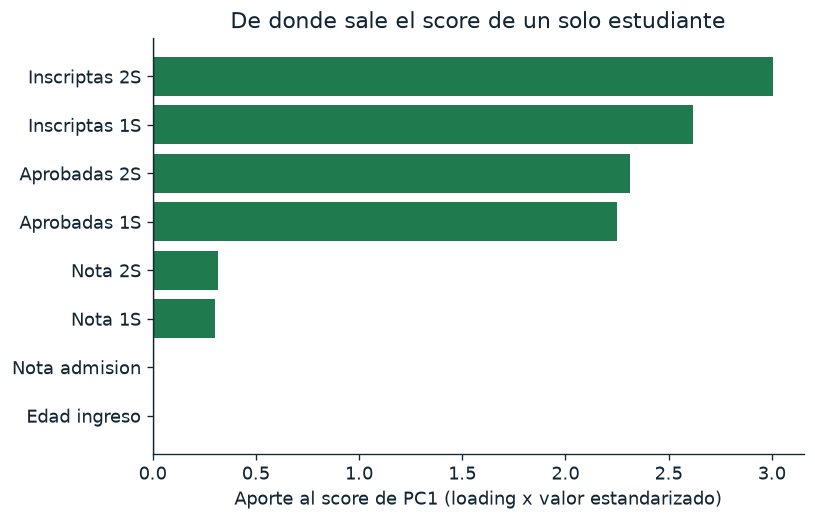

In [9]:
# El score de UN estudiante en PC1, abierto termino a termino
# Elegimos el estudiante con el score de PC1 mas alto: el caso mas nitido del eje de exito academico
i_est = int(np.argmax(scores[:, 0]))

x_i  = Xs[i_est]        # sus 8 valores estandarizados
phi1 = comp[0]          # los 8 loadings de PC1 (ya orientada hacia el exito academico)
prod = x_i * phi1       # cada termino de la suma
suma = float(prod.sum())

tabla_score = pd.DataFrame({
    "Variable": [etq[c] for c in academico],
    "Valor estandarizado (x_ij)": np.round(x_i, 3),
    "Loading PC1 (phi_j1)": np.round(phi1, 3),
    "Producto": np.round(prod, 3),
})
display(tabla_score)

# Verificaciones independientes
assert np.isclose(np.sum(phi1 ** 2), 1.0)                       # los loadings estan normalizados
assert pca.n_components_ == min(Xs.shape[0] - 1, p)             # hay min(n-1, p) componentes
signo = float(np.sign(np.dot(comp[0], pca.components_[0])))     # +1 o -1 segun la orientacion elegida
z_sklearn = signo * float(pca.transform(Xs[i_est].reshape(1, -1))[0, 0])
assert np.isclose(suma, z_sklearn)                              # la suma a mano = lo que devuelve sklearn
assert np.isclose(suma, scores[i_est, 0])                       # y = el score que dibujamos en el biplot

pct = float((scores[:, 0] < scores[i_est, 0]).mean() * 100)
print("Estudiante numero", i_est, "| desenlace:", est["Target"].to_numpy()[i_est])
print("Suma de los 8 productos :", round(suma, 4))
print("Score de pca.transform  :", round(z_sklearn, 4))
print("Supera al", round(pct, 1), "% de los estudiantes en PC1")

orden = np.argsort(-np.abs(prod))
print("\nLas tres variables que mas empujan su score:")
for j in orden[:3]:
    print("  ", etq[academico[j]], "-> aporta", round(float(prod[j]), 3),
          "(esta a", round(float(x_i[j]), 2), "desvios del promedio)")

# Cuanto aporta cada variable a este score, ordenado
fig, ax = plt.subplots(figsize=(7, 4.5))
colores = [COL["good"] if v >= 0 else COL["bad"] for v in prod[orden][::-1]]
ax.barh([etq[academico[j]] for j in orden][::-1], prod[orden][::-1], color=colores)
ax.axvline(0, color=COL["ink"], lw=0.8)
ax.set_xlabel("Aporte al score de PC1 (loading x valor estandarizado)")
ax.set_title("De donde sale el score de un solo estudiante")
guardar_figura("clase10_score_termino")
plt.show()

Leido asi, el score deja de ser una salida opaca del algoritmo. El estudiante elegido queda arriba en PC1 porque casi todas sus variables academicas estan varios desvios por encima del promedio y porque los loadings de PC1 las pesan a todas con el mismo signo: PC1 es, esencialmente, un promedio ponderado de rendimiento academico. Las variables que mas empujan su score son las que combinan un loading grande con un valor personal muy alejado de la media; una variable con loading grande pero valor tipico aporta poco, y una variable con valor extremo pero loading chico tampoco mueve la aguja. Se necesitan las dos cosas.

Eso tambien explica por que, sin haber usado nunca la etiqueta de desercion, los graduados terminan del lado alto del eje: estan alto en las mismas variables que PC1 pondera fuerte.

Hacer esta cuenta a mano una sola vez es lo que hace que la palabra *score* deje de ser abstracta: no es una coordenada magica, es una suma de ocho productos que cualquiera puede reproducir con una calculadora.

**Caso aplicado 1. De 4500 adjetivos a cinco factores: el modelo Big Five**

Desde principios del siglo XX los psicologos intentaron catalogar los terminos del lenguaje cotidiano que describen diferencias de personalidad. En 1936 Gordon Allport y Henry Odbert armaron una lista de unos 4500 terminos, un problema con un $p$ enorme y sin ninguna estructura visible. Con analisis factorial y la naciente tecnologia de computo, sucesivas investigaciones fueron condensando esa lista primero a 16 dimensiones y finalmente a 5, dando origen al modelo Big Five u OCEAN: Apertura, Responsabilidad, Extraversion, Amabilidad y Neuroticismo ([historia del Big Five](https://bigfive-test.com/articles/big_five_test_history_and_background)).

Un ejemplo con PCA explicita: De Raad y Barelds (2008) hicieron un estudio psicolexico del lexico holandes con 2365 items descriptivos de rasgos y aplicaron Analisis de Componentes Principales, obteniendo ocho factores que incluian los cinco clasicos mas Virtud, Competencia y Hedonismo ([De Raad y Barelds](https://www.researchgate.net/publication/277016573_Big_Five_Factor_Model_Theory_and_Structure)).

El punto es el mismo que estamos viendo, llevado a otra escala: cuando $p$ es enorme, las direcciones de maxima varianza permiten pasar de miles de columnas a un punado de factores compuestos que ademas se pueden nombrar e interpretar. Nosotros lo hacemos con 8 variables academicas; ellos lo hicieron con miles de adjetivos.

**Caso aplicado 2. PC1 como indice: el Nivel Socioeconomico**

Cuando decimos que PC1 funciona como un indice compuesto no es una metafora didactica: asi se construye buena parte de los indices de Nivel Socioeconomico que se usan en investigacion social. Filmer y Pritchett (2001), en *Demography*, estimaron la relacion entre riqueza del hogar y matriculacion escolar en India construyendo un indice de riqueza a partir de indicadores de propiedad de activos del hogar, y usaron PCA para derivar los ponderadores, es decir los loadings. El indice resulto robusto y sus resultados a nivel estadual se correspondieron con datos independientes de producto per capita y de pobreza ([Filmer y Pritchett, 2001](https://doi.org/10.1353/dem.2001.0003)).

En la practica, el indice se arma con activos del hogar (heladera, moto, bicicleta) y caracteristicas de la vivienda (tipo de piso, fuente de agua); despues los hogares se ordenan segun su valor en PC1 y se los agrupa en quintiles de NSE. La guia metodologica de referencia es Vyas y Kumaranayake (2006), en *Health Policy and Planning*, que revisa como se construyen estos indices, su validez y limitaciones, como elegir las variables y como pasar de los scores a grupos de NSE ([Vyas y Kumaranayake, 2006](https://academic.oup.com/heapol/article/21/6/459/612115)).

Hay un detalle que conviene discutir: la mayoria de estos trabajos usa **solo** la primera componente como indice. Literatura posterior propone promediar varias componentes, con el argumento de que PC1 suele explicar apenas una parte de la varianza total ([discusion sobre cuantas componentes usar](http://article.sapub.org/10.5923.j.statistics.20221203.03.html)). Es exactamente la pregunta que retomamos mas adelante cuando miremos el scree plot y la PVE acumulada.

**Caso aplicado 3. Nombrar componentes: percepcion de lacteos locales**

Un experimento de eleccion online realizado en Apulia, Italia, con 543 encuestados, investigo como perciben los consumidores los productos lacteos locales en tres aspectos: calidad, sustentabilidad y disponibilidad. Los autores aplicaron PCA sobre las respuestas al cuestionario y quedaron con cuatro componentes, que nombraron segun que items cargaban fuerte en cada uno: sensibilidad a los atributos de calidad, "lo local es mejor", "lo local es sustentable", y demanda de mayor disponibilidad. Luego relacionaron esas cuatro dimensiones con variables sociodemograficas de los encuestados ([Bimbo y colegas, 2022](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9179242/)).

Sirve como plantilla del flujo tipico en investigacion aplicada: se disena un cuestionario con muchos items correlacionados, se usa PCA para encontrar las dimensiones latentes de opinion, se nombra cada componente leyendo los loadings mas altos, y recien despues se estudia como esas dimensiones se relacionan con otras variables. El nombre de la componente no sale del algoritmo, lo pone quien analiza.

<a name="s3r"></a>
### 3.1 Reconstruir un dato a partir de sus componentes

Hasta aca usamos PCA en una sola direccion: partimos de las variables originales y llegamos a los scores. Vale la pena recorrer el camino de vuelta, porque es lo que da sentido a la palabra *comprimir*. Si los scores y los loadings guardan la informacion de la tabla original, entonces tenemos que poder **reconstruir** cada dato a partir de ellos.

La formula es esta:

$$x_{ij} \;\approx\; \sum_{m=1}^{M} z_{im}\,\phi_{jm}$$

Despacio, simbolo por simbolo:

- $x_{ij}$: el dato que queremos reconstruir, es decir el valor de la variable $j$ para la observacion $i$, ya centrado (en nuestro caso, estandarizado).
- $M$: cuantas componentes usamos para reconstruir. Si $M$ es chico, estamos aproximando la tabla entera con muy pocas dimensiones; si $M = p$, la reconstruccion es **exacta**.
- $z_{im}$: el score de la observacion $i$ en la componente $m$, o sea la coordenada de ese estudiante sobre esa direccion.
- $\phi_{jm}$: el loading de la variable $j$ en la componente $m$, o sea cuanto pesa esa variable en esa direccion.

**En palabras simples.** Para reconstruir un dato agarras el score de esa observacion en cada componente, lo multiplicas por el loading de esa variable en esa misma componente, y sumas esos productos sobre las $M$ componentes que decidiste usar. Cuantas mas componentes sumes, mas cerca vas a quedar del valor real.

**Por que funciona.** La reconstruccion hace exactamente el camino inverso al que abrimos termino a termino en la seccion anterior, deshaciendo la combinacion lineal con los mismos loadings. Es una relacion de ida y vuelta: los loadings sirven para armar los scores y tambien para desarmarlos. Cuando usamos las $p$ componentes no se pierde nada, porque PCA no es mas que una **rotacion** del sistema de coordenadas: los mismos puntos, mirados desde otros ejes.

**Y no es una aproximacion cualquiera.** Se puede demostrar (no lo vamos a hacer aca) que esta es **la mejor** aproximacion posible con $M$ dimensiones: ninguna otra eleccion de $M$ variables nuevas construidas como combinaciones lineales de las originales reconstruye la tabla con menos error cuadratico. Eso es lo que hace a PCA optimo para comprimir, y no simplemente una forma mas de resumir datos.

In [10]:
# Reconstruir UN dato concreto: el estudiante i_rec, en la variable j, usando M componentes
i_rec  = 108                                                # un estudiante concreto del dataset
var_j  = "Curricular units 2nd sem (approved)"              # la variable que vamos a reconstruir
j = academico.index(var_j)

media_j  = X.values.mean(axis=0)[j]                         # media y desvio con los que se estandarizo
desvio_j = X.values.std(axis=0)[j]
real = X.values[i_rec, j]                                   # el valor real, en su escala original

filas = []
for M in range(1, p + 1):
    # x_ij aproximado = suma sobre m=1..M de z_im * phi_jm   (en escala estandarizada)
    aprox_std = float(scores[i_rec, :M] @ comp[:M, j])
    # verificacion independiente: la misma suma escrita a mano, termino por termino
    a_mano = sum(scores[i_rec, m] * comp[m, j] for m in range(M))
    assert np.isclose(aprox_std, a_mano)
    aprox_orig = aprox_std * desvio_j + media_j             # deshacemos la estandarizacion
    filas.append({"M usadas": M,
                  "reconstruido (estand.)": round(aprox_std, 3),
                  "reconstruido (escala original)": round(aprox_orig, 3),
                  "error absoluto": round(abs(aprox_orig - real), 3)})

tabla_rec = pd.DataFrame(filas)
err = tabla_rec["error absoluto"].to_numpy()

# Con las p componentes la reconstruccion es exacta: es solo un cambio de coordenadas
assert np.isclose(scores[i_rec] @ comp[:, j], Xs[i_rec, j], atol=1e-8)
assert np.isclose(tabla_rec["reconstruido (escala original)"].iloc[-1], real, atol=1e-2)
# y ninguna reconstruccion parcial le gana a la completa
assert err[-1] <= err.min() + 1e-9

print("Estudiante", i_rec, "| variable:", etq[var_j],
      "| desenlace:", est["Target"].iloc[i_rec], "| valor real:", real)
display(tabla_rec)

Estudiante 108 | variable: Aprobadas 2S | desenlace: Dropout | valor real: 5.0


,M usadas,reconstruido (estand.),reconstruido (escala original),error absoluto
0,1,0.384,5.595,0.595
1,2,0.383,5.591,0.591
2,3,0.377,5.571,0.571
3,4,0.375,5.566,0.566
4,5,0.262,5.226,0.226
5,6,0.258,5.212,0.212
6,7,0.216,5.087,0.087
7,8,0.187,5.000,0.000


Vale la pena leer la tabla fila por fila. Con $M = 1$ la reconstruccion ya cae bastante cerca del valor real, pero queda error: la primera componente resume la **tendencia general** de exito academico, y ubica a este estudiante en el lugar que le corresponde sobre ese eje, no en su valor exacto. A medida que sumamos componentes vamos recuperando el **matiz propio** de esa observacion, aquello en lo que se aparta de la tendencia comun, y el error tiende a achicarse. Con las ocho componentes el error es cero hasta la precision de la maquina: como no descartamos ninguna direccion, no hay nada que perder, solo cambiamos el sistema de coordenadas.

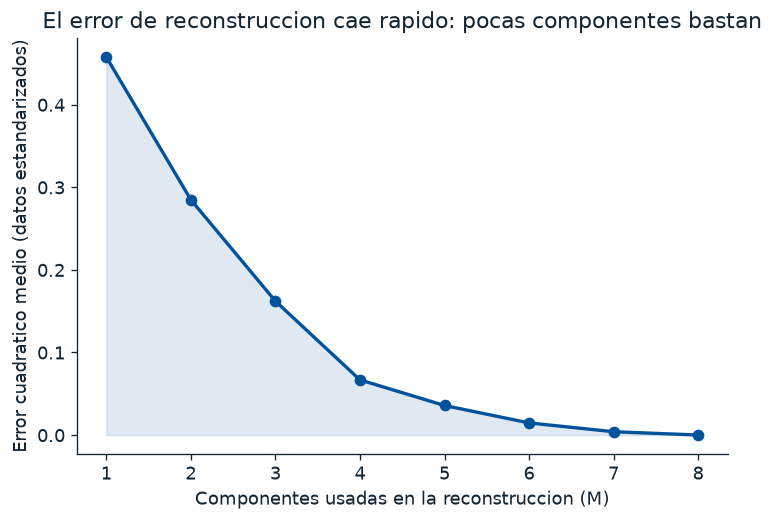

ECM con M=1: 0.458 | con M=2: 0.285 | con M=8: 0.0
Con M=2 el error ya cayo un 37.8 % respecto de usar una sola componente


In [11]:
# Error de reconstruccion de TODO el dataset en funcion de cuantas componentes usamos
Ms = np.arange(1, p + 1)
ecm = np.array([np.mean((scores[:, :M] @ comp[:M, :] - Xs) ** 2) for M in Ms])

# Verificacion independiente: el error medio por celda es la varianza que dejan afuera
# las componentes no usadas, dividida por el numero de variables
var_comp = pca.explained_variance_ratio_ * Xs.var(axis=0).sum()
ecm_teo = np.array([var_comp[M:].sum() / p for M in Ms])
assert np.allclose(ecm, ecm_teo, atol=1e-8)
assert np.all(np.diff(ecm) < 0)                  # agregar componentes siempre reduce el error
assert np.isclose(ecm[-1], 0, atol=1e-10)        # con las p componentes, error nulo

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(Ms, ecm, "o-", color=COL["primary"], lw=2)
ax.fill_between(Ms, 0, ecm, color=COL["primary"], alpha=0.12)
ax.set_xlabel("Componentes usadas en la reconstruccion (M)")
ax.set_ylabel("Error cuadratico medio (datos estandarizados)")
ax.set_title("El error de reconstruccion cae rapido: pocas componentes bastan")
guardar_figura("clase10_reconstruccion")
plt.show()

print("ECM con M=1:", round(float(ecm[0]), 3),
      "| con M=2:", round(float(ecm[1]), 3),
      "| con M=" + str(p) + ":", round(float(ecm[-1]), 12))
print("Con M=2 el error ya cayo un",
      round(float((1 - ecm[1] / ecm[0]) * 100), 1), "% respecto de usar una sola componente")

display(callout("El error que deja una reconstruccion con M componentes es exactamente la varianza "
                "que descartamos al quedarnos con esas M direcciones. En la seccion que sigue "
                "volvemos sobre esa cuenta para elegir cuantas componentes retener.",
                "info", "Para retener"))

**Predecir.** Si reconstruimos la tabla con $M$ componentes y el error cuadratico medio da cero, que podemos afirmar sobre las variables originales?

<details><summary>Ver respuesta</summary>

Que el bloque de variables vive, en realidad, en un espacio de $M$ dimensiones: hay $p - M$ direcciones sin ninguna variacion, porque algunas variables son combinaciones lineales exactas de las otras. En datos reales eso casi nunca pasa de forma perfecta, pero cuanto mas rapido cae la curva del error, mas cerca estamos de esa situacion y mas justificado esta quedarse con pocas componentes.

</details>

<a name="s4"></a>
## 4. Decisiones practicas: escalar y cuantos componentes

Dos decisiones definen el resultado de una PCA.

**Estandarizar.** PCA maximiza varianza, asi que una variable con varianza enorme domina el resultado solo por la escala en que esta medida. Antes de ver el codigo, hagamos una prediccion.

**Cuantos componentes.** Miramos el **scree plot** (varianza por componente) buscando el **codo**, y la **varianza acumulada** para llegar a un umbral (80% o 90%). La proporcion de varianza explicada por los primeros $M$ componentes es el $R^2$ de la aproximacion. No hay una regla objetiva unica: en no supervisado es, en parte, un juicio.

**Predecir.** Vamos a correr PCA sobre el bloque academico **sin estandarizar**. Que variable pensas que va a dominar la primera componente, y por que?

<details><summary>Ver respuesta</summary>

La **nota de admision**. Esta en una escala de 0 a 200, con una varianza muchisimo mayor que las materias aprobadas (que van de 0 a ~10). Como PCA busca maxima varianza, sin estandarizar la PC1 se vuelve casi solo esa variable, no porque sea mas importante, sino por su escala.

</details>

Variable que domina PC1 sin escalar: Nota admision


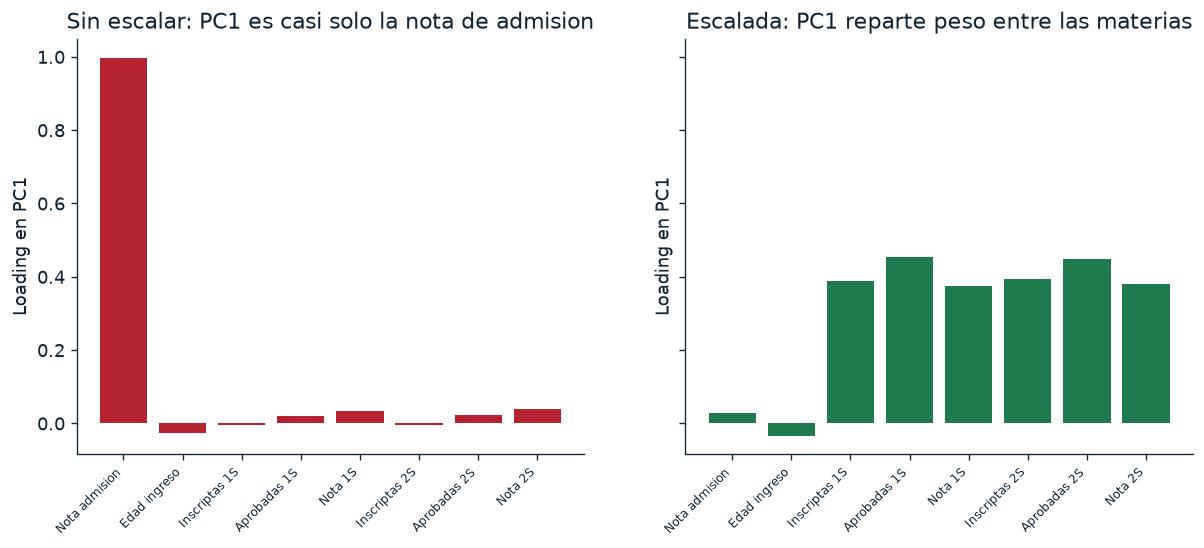

In [12]:
# Escalado como descubrimiento: PCA sin escalar vs escalada
pca_raw = PCA().fit(X.values - X.values.mean(axis=0))     # centrada pero SIN escalar
pca_std = PCA().fit(StandardScaler().fit_transform(X))    # centrada Y escalada

# Sin escalar, la variable de mayor varianza (nota de admision) domina la PC1
dom = academico[int(np.argmax(np.abs(pca_raw.components_[0])))]
print("Variable que domina PC1 sin escalar:", etq[dom])
assert dom == "Admission grade"

l_raw = pca_raw.components_[0] * np.sign(pca_raw.components_[0][academico.index("Admission grade")])
l_std = pca_std.components_[0] * np.sign(pca_std.components_[0].mean())
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
axs[0].bar(range(p), l_raw, color=COL["bad"]); axs[0].set_title("Sin escalar: PC1 es casi solo la nota de admision")
axs[1].bar(range(p), l_std, color=COL["good"]); axs[1].set_title("Escalada: PC1 reparte peso entre las materias")
for a in axs:
    a.set_xticks(range(p)); a.set_xticklabels([etq[c] for c in academico], rotation=45, ha="right", fontsize=7)
    a.set_ylabel("Loading en PC1")
guardar_figura("clase10_escalado")
plt.show()

display(callout("Salvo que todas las variables esten en la misma unidad, se estandariza cada una "
                "a media cero y desvio uno antes de PCA. Si no, la escala de medicion decide el resultado.",
                tipo="warn", titulo="Regla practica"))

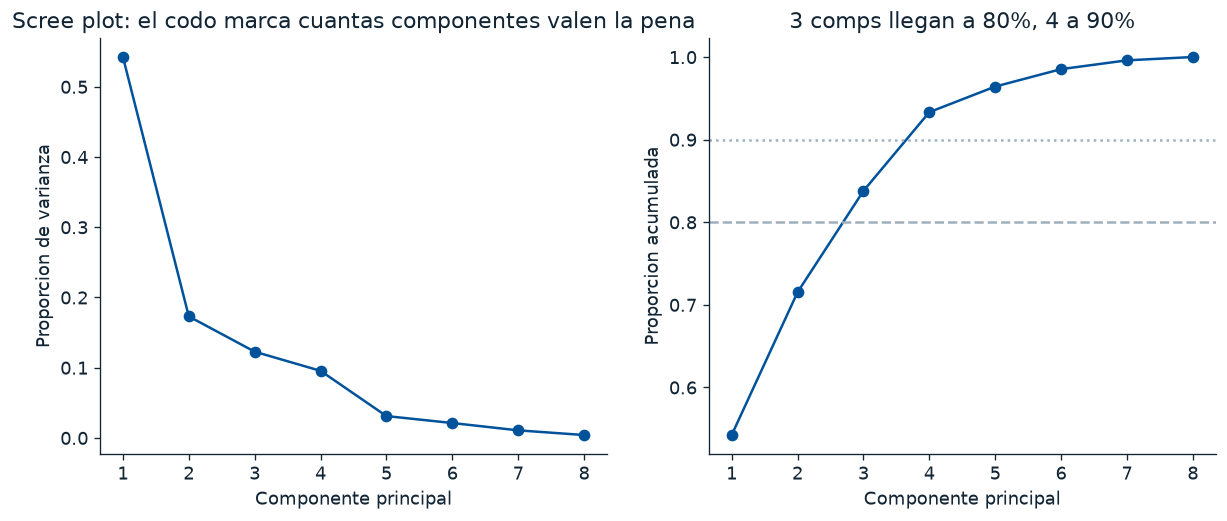

In [13]:
# Cuantos componentes: scree plot y varianza acumulada
pve = pca_std.explained_variance_ratio_
cum = np.cumsum(pve)
k80 = int(np.searchsorted(cum, 0.80) + 1)
k90 = int(np.searchsorted(cum, 0.90) + 1)

t = np.arange(1, p + 1)
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
axs[0].plot(t, pve, "o-", color=COL["primary"])
axs[0].set_title("Scree plot: el codo marca cuantas componentes valen la pena")
axs[0].set_xlabel("Componente principal"); axs[0].set_ylabel("Proporcion de varianza")
axs[1].plot(t, cum, "o-", color=COL["primary"])
axs[1].axhline(0.8, color=COL["grey"], ls="--"); axs[1].axhline(0.9, color=COL["grey"], ls=":")
axs[1].set_title(str(k80) + " comps llegan a 80%, " + str(k90) + " a 90%")
axs[1].set_xlabel("Componente principal"); axs[1].set_ylabel("Proporcion acumulada")
guardar_figura("clase10_scree")
plt.show()

display(callout("La proporcion de varianza explicada por los primeros M componentes es el "
                "<b>R&sup2;</b> de la mejor aproximacion de rango M a los datos. No hay una respuesta "
                "unica y simple a cuantos componentes usar: se elige mirando el codo y el problema.",
                tipo="info", titulo="PVE = R cuadrado, y una decision con criterio"))

### Cuanta varianza hay para repartir, y como se reparte

Antes de mirar el scree plot conviene tener claro que es exactamente lo que el grafico esta repartiendo. La respuesta corta: la **varianza total** de los datos, que es un numero fijo, y las componentes se la reparten entre ellas sin dejar nada afuera.

**1. La varianza total.** Llamamos varianza total a la suma de las varianzas de todas las variables, una vez centradas en cero:

$$V_{\text{total}} \;=\; \sum_{j=1}^{p} \operatorname{Var}(x_j) \;=\; \sum_{j=1}^{p} \frac{1}{n}\sum_{i=1}^{n} x_{ij}^{2}$$

donde:

- $p$ es la cantidad de variables (en nuestro caso las 8 variables academicas),
- $n$ es la cantidad de estudiantes,
- $x_{ij}$ es el valor centrado de la variable $j$ para el estudiante $i$,
- $\operatorname{Var}(x_j)$ es la varianza de la variable $j$.

Si ademas de centrar **estandarizamos**, cada variable queda con desvio 1 y por lo tanto con varianza 1. Entonces la varianza total no depende de las unidades ni de la escala de nada: es exactamente $p$. Cada variable aporta una unidad de varianza al pozo comun. Con nuestras 8 variables academicas estandarizadas, hay 8 unidades de varianza para repartir.

**2. Lo que explica cada componente es su autovalor.** La varianza de los scores de la componente $m$ es el autovalor $\lambda_m$ de la matriz de correlaciones, el mismo objeto que aparecio cuando vimos como se calculan los loadings:

$$\lambda_m \;=\; \operatorname{Var}(z_m)$$

donde:

- $z_m$ es el vector de scores de la componente $m$, es decir la coordenada de cada estudiante sobre esa direccion,
- $\lambda_m$ es el autovalor asociado a esa componente.

En `scikit-learn` esos autovalores estan en `pca.explained_variance_`. Como las $p$ componentes forman una base completa del espacio, sus autovalores suman la varianza total. Rotar los ejes no crea ni destruye varianza, solo la reordena.

**3. La PVE.** La proporcion de varianza explicada por la componente $m$ es simplemente su porcion del pozo:

$$\text{PVE}_m \;=\; \frac{\lambda_m}{\sum_{k=1}^{p}\lambda_k}$$

donde:

- $\text{PVE}_m$ es la proporcion de varianza explicada por la componente $m$, un numero entre 0 y 1,
- $\lambda_m$ es el autovalor de esa componente,
- el denominador es la varianza total.

La PVE acumulada hasta $M$ componentes es la suma de las primeras $M$ proporciones, y si sumamos las $p$ llegamos exactamente a 1: entre todas explican todo.

**4. La conexion clave: maxima varianza y minimo error son la misma cosa.** En la seccion 3.1 aproximamos los datos con las primeras $M$ componentes y medimos el error de reconstruccion, es decir lo que quedaba afuera. Vale la pena unir las dos cuentas, porque la varianza total se parte de manera exacta en dos pedazos: lo que capturan las primeras $M$ componentes, mas el error de reconstruccion que queda al usar solo esas $M$. Nada se pierde y nada se agrega: uno de los pedazos crece justo lo que el otro se achica.

Y como la varianza total es un numero fijo (es $p$, no depende de cuantas componentes usemos), la consecuencia es directa: **elegir las direcciones que maximizan la varianza explicada es exactamente lo mismo que elegir el subespacio que minimiza el error de reconstruccion**. No son dos criterios que casualmente dan parecido, son el mismo criterio escrito de dos formas. Esa es la razon de fondo por la que las dos definiciones de PCA que venimos usando, la direccion de maxima varianza de la seccion 2 y el subespacio mas cercano a los datos de la seccion 3.1, describen el mismo objeto visto desde dos angulos.

**5. La PVE es un $R^2$.** De esa misma particion se desprende una lectura comoda. En regresion lineal, el $R^2$ compara la variabilidad que el modelo logra explicar contra la variabilidad total de la respuesta. Aca pasa lo mismo, con la diferencia de que no hay una variable respuesta sino el conjunto entero de las $p$ variables: la PVE acumulada de las primeras $M$ componentes es la proporcion de la variabilidad total de los datos que la aproximacion de rango $M$ consigue explicar. Es decir, es el $R^2$ de la reconstruccion. Cuando leamos que dos componentes acumulan cierta proporcion, se puede decir con las mismas palabras que se usaban en regresion: esa es la fraccion de la variabilidad de las 8 variables que sobrevive al resumen en dos coordenadas.

In [14]:
# Verificacion numerica: varianza total, autovalores y PVE
# Cada resultado se contrasta con un calculo independiente hecho a mano.
n_est = Xs.shape[0]
assert Xs.shape[1] == p

# --- Punto 1: la varianza total de los datos estandarizados es exactamente p ---
# StandardScaler divide por el desvio poblacional, asi que usamos ddof=0
var_por_variable = Xs.var(axis=0, ddof=0)
var_total = float(var_por_variable.sum())
assert np.allclose(var_por_variable, 1.0, atol=1e-8)   # cada variable estandarizada tiene varianza 1
assert np.isclose(var_total, p, atol=1e-8)             # la varianza total es igual a p

# --- Punto 2: la varianza explicada por cada componente es su autovalor ---
autovalores = pca.explained_variance_                  # sklearn usa denominador n-1
autoval_manual = scores.var(axis=0, ddof=1)            # calculo independiente sobre los scores
assert np.allclose(autovalores, autoval_manual, atol=1e-8)

# calculo independiente 2: autovalores de la matriz de correlaciones,
# reescalados de denominador n a denominador n-1 para poder compararlos
autoval_eig = np.sort(np.linalg.eigvalsh(np.corrcoef(Xs, rowvar=False)))[::-1]
assert np.allclose(autovalores, autoval_eig * n_est / (n_est - 1), rtol=1e-6)

# los autovalores suman la varianza total (con el mismo denominador)
assert np.isclose(float(autovalores.sum()), p * n_est / (n_est - 1), rtol=1e-8)
assert np.isclose(float(scores.var(axis=0, ddof=0).sum()), p, atol=1e-6)

# --- Punto 3: PVE individual y acumulada ---
pve_manual = autovalores / autovalores.sum()
pve_acum_manual = np.cumsum(pve_manual)
assert np.allclose(pve_manual, pca.explained_variance_ratio_, atol=1e-10)
assert np.allclose(pve_manual, pve, atol=1e-10)        # coincide con la pve ya calculada en la seccion 3
assert np.all(pve_manual >= 0) and np.all(pve_manual <= 1)
assert np.isclose(pve_acum_manual[-1], 1.0, atol=1e-10)

tabla_pve = pd.DataFrame({
    "Componente": [f"PC{m+1}" for m in range(p)],
    "Autovalor": np.round(autovalores, 3),
    "PVE": np.round(pve_manual, 3),
    "PVE acumulada": np.round(pve_acum_manual, 3),
}).set_index("Componente")

print(f"Estudiantes: {n_est}   Variables: {p}")
print(f"Varianza total (suma de varianzas de las variables estandarizadas): {var_total:.3f}")
print(f"PVE de las dos primeras componentes: {pve_acum_manual[1]:.3f}")
print(f"PVE acumulada con {p} componentes: {pve_acum_manual[-1]:.3f}")
print()
print(tabla_pve)

Estudiantes: 4424   Variables: 8
Varianza total (suma de varianzas de las variables estandarizadas): 8.000
PVE de las dos primeras componentes: 0.715
PVE acumulada con 8 componentes: 1.000

            Autovalor    PVE  PVE acumulada
Componente                                 
PC1             4.339  0.542          0.542
PC2             1.383  0.173          0.715
PC3             0.982  0.123          0.838
PC4             0.763  0.095          0.933
PC5             0.248  0.031          0.964
PC6             0.169  0.021          0.985
PC7             0.085  0.011          0.996
PC8             0.032  0.004          1.000


> **Ejercicio 1.** Escribi el codigo que calcule **cuantos** componentes principales hacen falta para explicar al menos el **90%** de la varianza del bloque academico. Pista: usa la suma acumulada de `pca_std.explained_variance_ratio_`.

In [15]:
# Solucion: componentes necesarios para un umbral de varianza
umbral = 0.90
n_comp = int(np.searchsorted(np.cumsum(pca_std.explained_variance_ratio_), umbral) + 1)
print("Para explicar el", int(umbral * 100), "% hacen falta", n_comp, "componentes")
assert 0 < n_comp <= p

Para explicar el 90 % hacen falta 4 componentes


<a name="s5"></a>
## 5. Metodos no lineales: t-SNE y UMAP

PCA es **lineal**: sus componentes son combinaciones lineales de las variables, y solo captura estructura describible con direcciones rectas. Cuando la estructura interesante es curva o esta en grupos separados de forma no lineal, PCA se queda corto.

**t-SNE** y **UMAP** construyen una representacion 2D que preserva sobre todo la **vecindad local**: puntos parecidos quedan cerca. Son excelentes para *visualizar* grupos, pero no preservan bien las distancias globales, dependen de hiperparametros (la *perplexity*, el numero de vecinos) y sus ejes no tienen interpretacion. No estan en el capitulo 12: los mostramos como complemento para explorar, no para inferir.

C:\Users\au805392\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


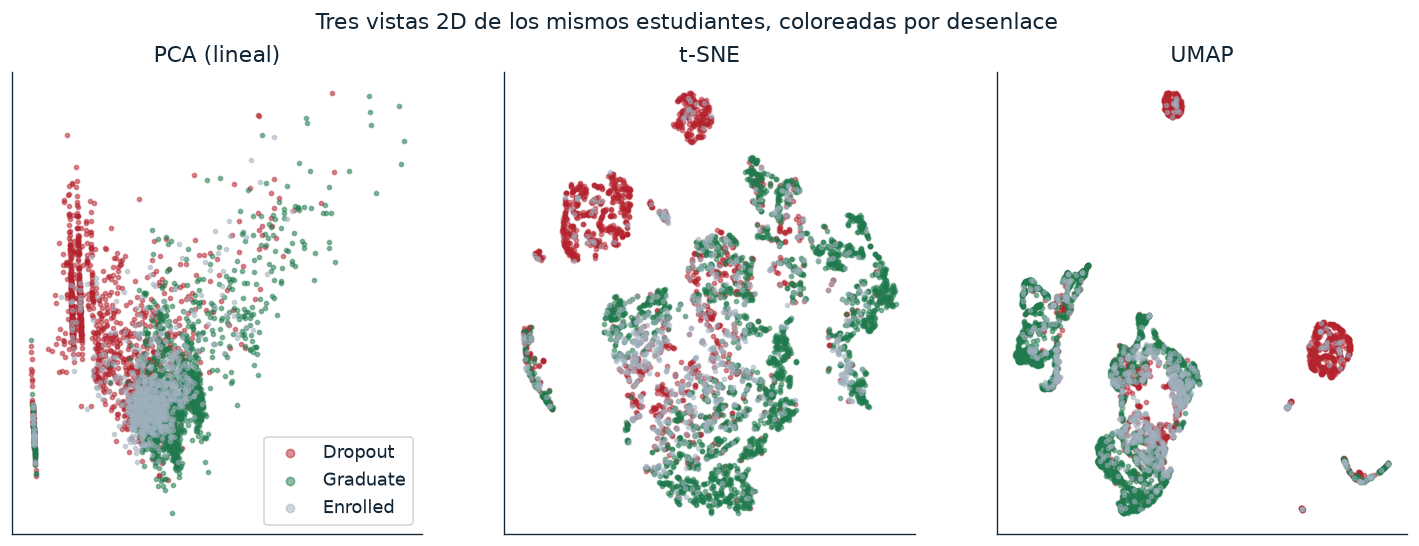

In [16]:
# En Colab, umap-learn no siempre viene preinstalado; localmente ya esta.
try:
    import umap
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "umap-learn"])
    import umap

Xs = StandardScaler().fit_transform(X)
emb_pca = PCA(n_components=2).fit_transform(Xs)
emb_tsne = TSNE(n_components=2, random_state=SEED, init="pca", perplexity=30).fit_transform(Xs)
emb_umap = umap.UMAP(n_components=2, random_state=SEED).fit_transform(Xs)

tg = est["Target"].to_numpy()
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for ax, emb, ti in zip(axs, [emb_pca, emb_tsne, emb_umap], ["PCA (lineal)", "t-SNE", "UMAP"]):
    for g in ["Dropout", "Graduate", "Enrolled"]:
        m = tg == g
        ax.scatter(emb[m, 0], emb[m, 1], s=6, alpha=0.5, color=COL_TARGET[g], label=g)
    ax.set_title(ti); ax.set_xticks([]); ax.set_yticks([])
axs[0].legend(markerscale=2)
fig.suptitle("Tres vistas 2D de los mismos estudiantes, coloreadas por desenlace")
guardar_figura("clase10_no_lineales")
plt.show()

display(callout("t-SNE y UMAP deforman las distancias globales para preservar las locales: la "
                "distancia entre dos grupos lejanos en el grafico <b>no</b> es interpretable, y cambiar "
                "un hiperparametro cambia el dibujo. Usalos para descubrir grupos, nunca para medir.",
                tipo="warn", titulo="Cuidado con la interpretacion"))

<a name="s6"></a>
## 6. Ejercicio de cierre: perfiles latentes en attrition

Ahora aplicas todo lo visto a un dataset que **ya conoces**: el de rotacion de personal (attrition) de las clases anteriores. La idea que cierra el capitulo es que muchas tecnicas, entre ellas el clustering, se pueden correr sobre los primeros $M$ scores de PCA en vez de sobre las variables originales, tratandolos como una **version menos ruidosa** de los datos.

**Consigna.** Sobre el bloque de variables de carrera de los empleados: (1) estandarizar y calcular la PCA; (2) quedarse con los primeros componentes; (3) correr K-means sobre esos scores para descubrir **perfiles latentes** de empleados; (4) perfilar cada grupo y cruzarlo con la rotacion. Intenta completarlo antes de mirar la solucion.

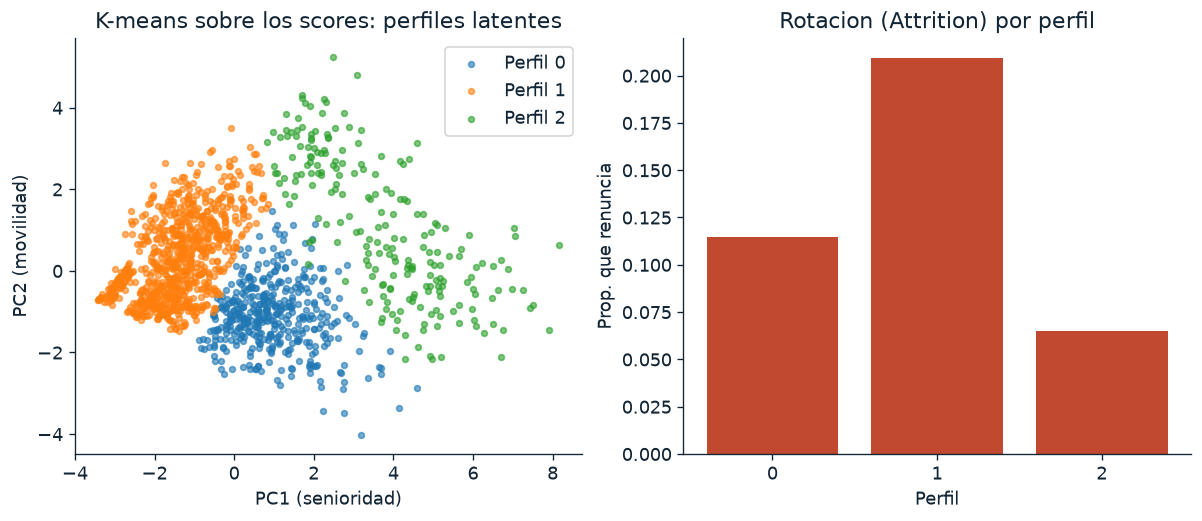

perfil                        0       1        2
Age                        36.2    34.3     48.3
TotalWorkingYears          11.9     7.2     25.8
MonthlyIncome            6216.8  4295.0  15602.0
JobLevel                    2.1     1.5      4.1
YearsAtCompany             10.4     3.4     14.5
YearsInCurrentRole          7.4     1.9      6.9
YearsWithCurrManager        7.4     1.9      6.5
YearsSinceLastPromotion     3.8     0.7      4.9
NumCompaniesWorked          1.9     2.9      3.6


In [17]:
# Solucion del ejercicio de cierre (attrition)
hr = pd.read_csv(URL_DATOS)
carrera = ["Age", "TotalWorkingYears", "MonthlyIncome", "JobLevel", "YearsAtCompany",
           "YearsInCurrentRole", "YearsWithCurrManager", "YearsSinceLastPromotion", "NumCompaniesWorked"]

# 1-2. PCA sobre el bloque estandarizado y primeros M scores (version menos ruidosa)
M = 3
Z = PCA(n_components=M, random_state=SEED).fit_transform(StandardScaler().fit_transform(hr[carrera]))

# 3. K-means sobre los scores
k = 3
km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(Z)
hr = hr.assign(perfil=km.labels_)
assert len(np.unique(km.labels_)) == k

# 4. Perfilar: medias por cluster y rotacion por perfil
signo = np.sign(np.corrcoef(Z[:, 0], hr["TotalWorkingYears"])[0, 1])
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
for c in range(k):
    m = km.labels_ == c
    axs[0].scatter(Z[m, 0] * signo, Z[m, 1], s=12, alpha=0.6, label="Perfil " + str(c))
axs[0].set_xlabel("PC1 (senioridad)"); axs[0].set_ylabel("PC2 (movilidad)")
axs[0].set_title("K-means sobre los scores: perfiles latentes"); axs[0].legend()
rot = pd.crosstab(hr["perfil"], hr["Attrition"], normalize="index")["Yes"]
axs[1].bar(rot.index.astype(str), rot.values, color=COL["accent"])
axs[1].set_title("Rotacion (Attrition) por perfil"); axs[1].set_xlabel("Perfil"); axs[1].set_ylabel("Prop. que renuncia")
guardar_figura("clase10_perfiles")
plt.show()
print(hr.groupby("perfil")[carrera].mean().round(1).T)

display(callout("Los perfiles son un <b>punto de partida para hipotesis</b>, no una verdad del dataset. "
                "El clustering no es robusto: cambia con la estandarizacion, el numero de componentes y k. "
                "Conviene repetirlo con distintas opciones y quedarse con los patrones que persisten.",
                tipo="success", titulo="Como reportar perfiles con cuidado"))

<a name="quiz"></a>
## Autoevaluacion

Tres preguntas para chequear las ideas centrales. Elegi y apreta **Corregir**.

In [18]:
Q = [("Que es la primera componente principal, geometricamente?",
      ["La variable de mayor varianza", "La direccion de maxima varianza (y la recta mas cercana a los puntos)", "El promedio de las variables"], 1),
     ("Antes de PCA, cuando conviene estandarizar las variables?",
      ["Nunca", "Solo si estan en unidades distintas o varianzas muy dispares", "Siempre que haya mas de 2"], 1),
     ("Que mide la proporcion de varianza explicada (PVE) por los primeros M componentes?",
      ["El error de clustering", "El R2 de la mejor aproximacion de rango M", "La correlacion media"], 1)]
ws = [W.RadioButtons(options=opts, description="P" + str(i + 1),
                     style={"description_width": "initial"}, value=None)
      for i, (_, opts, _) in enumerate(Q)]
out = W.Output()
for (stem, _, _), w in zip(Q, ws):
    display(W.HTML("<b>" + stem + "</b>")); display(w)
def _corregir(_):
    s = sum(1 for (_, opts, ans), w in zip(Q, ws) if w.value == opts[ans])
    with out:
        out.clear_output(); print("Puntaje:", s, "/", len(Q))
btn = W.Button(description="Corregir", button_style="primary")
btn.on_click(_corregir)
display(btn, out)

HTML(value='<b>Que es la primera componente principal, geometricamente?</b>')

RadioButtons(description='P1', options=('La variable de mayor varianza', 'La direccion de maxima varianza (y l…

HTML(value='<b>Antes de PCA, cuando conviene estandarizar las variables?</b>')

RadioButtons(description='P2', options=('Nunca', 'Solo si estan en unidades distintas o varianzas muy dispares…

HTML(value='<b>Que mide la proporcion de varianza explicada (PVE) por los primeros M componentes?</b>')

RadioButtons(description='P3', options=('El error de clustering', 'El R2 de la mejor aproximacion de rango M',…

Button(button_style='primary', description='Corregir', style=ButtonStyle())

Output()

**Caso aplicado 4. Reducir 32 medidas de comportamiento a unas pocas dimensiones**

Arguello y Crescenzi (2019) analizaron con PCA hasta 32 medidas de comportamiento por sesion (cantidad de queries, clics, tiempos de permanencia, scrolls, mouseovers) capturadas en tres estudios de busqueda de informacion. La pregunta no era predecir, era entender: que fenomenos latentes capturan realmente esas medidas, y como se relacionan con las percepciones que reporta la persona al terminar la tarea (carga de trabajo, dificultad, presion de tiempo, engagement) ([Arguello y Crescenzi, ICTIR 19, paginas 177 a 184](https://doi.org/10.1145/3341981.3344222); [PDF abierto](https://ils.unc.edu/~jarguell/ArguelloICTIR2019.pdf)).

Vale la pena mirar las decisiones metodologicas, porque son las mismas que tomamos en esta clase:

- **Escalado.** Trabajaron sobre la matriz de correlacion y no sobre la de covarianza, porque las medidas estan en escalas muy distintas: las queries se cuentan en decenas y las duraciones en cientos de segundos. Eso equivale a estandarizar antes de aplicar PCA, exactamente lo que vimos en la seccion 4.
- **Cuantas componentes.** Retuvieron las de autovalor mayor a 1 y, ademas, exigieron que cada componente tuviera al menos dos variables con loadings altos (0.50 o mas en valor absoluto). El segundo criterio evita quedarse con componentes que en los hechos son una sola variable disfrazada.
- **Rotacion varimax.** Rotaron la solucion para mejorar la interpretabilidad, favoreciendo que cada variable cargue fuerte en una componente y debil en las demas. Es practica estandar en este tipo de trabajos; ISLP no la desarrolla, pero conviene saber que existe cuando lean papers.
- **Nombrado.** Cada componente recibio un nombre segun las medidas que cargaban fuerte, por ejemplo abandono de queries o ritmo de interaccion.
- **Uso posterior.** Los scores de las componentes entraron como predictores en un modelo de regresion multinivel. Es el flujo completo: primero reducir la dimension, despues modelar con las componentes.

Un resultado ilustrativo: en uno de los estudios, el PCA con rotacion varimax dio una solucion de seis componentes que explico el 76 por ciento de la varianza total de 24 medidas de comportamiento. Del mismo modo que en nuestro caso unas pocas componentes alcanzan para resumir el desempeno academico, ahi seis dimensiones alcanzaron para resumir como una persona se comporta frente a un buscador.

<a name="cierre"></a>
## Cierre

Recorrimos PCA de punta a punta: de la redundancia entre variables correlacionadas, a la intuicion en 2D (la recta de maxima varianza, que es tambien la mas cercana), a su generalizacion a muchas dimensiones con el biplot, a las decisiones de escalar y elegir cuantos componentes, a la mencion de los metodos no lineales, y al cierre aplicando PCA + clustering sobre datos que ya conocias.

**Para seguir.** El capitulo 12 cubre ademas otros usos de las componentes (Seccion 12.2.5), la imputacion de faltantes por *matrix completion* (12.3) y el detalle de los metodos de clustering (12.4). En las Clases 11 y 12 la idea de representar datos en pocas dimensiones reaparece como *embeddings* de texto.

## Apendice: hoja de referencia

| concepto | formula o idea |
|---|---|
| Componente principal | $Z_m = \sum_j \phi_{jm} X_j$, con $\sum_j \phi_{jm}^2 = 1$, de maxima varianza |
| Loadings | los $\phi_{jm}$: cuanto pesa cada variable en la componente $m$ |
| Scores | $z_{im}$: la coordenada de la observacion $i$ en la componente $m$ |
| Doble lectura | maxima varianza $\equiv$ recta/plano mas cercano a los puntos |
| PVE | proporcion de varianza explicada; igual al $R^2$ de la aproximacion |
| Estandarizar | media 0 y desvio 1 por variable, salvo unidad comun |
| Cuantos componentes | codo del scree plot o umbral de varianza acumulada (80 a 90%) |
| PCA + clustering | correr K-means sobre los primeros M scores (version menos ruidosa) |

---
**Ejecutar / compartir esta notebook.** Abrila en Google Colab y elegi Entorno de ejecucion -> Ejecutar todo; no hace falta instalar nada localmente.

*Fuentes: ISLP (James et al., 2023), capitulo 12; dataset de desercion UCI id 697 (CC BY 4.0). Cada numero de esta notebook se recalcula y se verifica con asserts.*